<a href="https://colab.research.google.com/github/RohitKhobare/Design_And_Analysis_of_Algorithm/blob/main/DAA_LA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import random
import sys

class Item:
    def __init__(self, value, weight, index):
        self.value = value
        self.weight = weight
        self.index = index
        self.ratio = value / weight

    def __lt__(self, other):
        return self.ratio > other.ratio

def fractional_knapsack(capacity, items):
    items.sort()

    total_value = 0.0
    fractions = [0.0] * len(items)
    current_weight = 0

    for item in items:
        if current_weight + item.weight <= capacity:
            current_weight += item.weight
            total_value += item.value
            fractions[item.index] = 1.0
        else:
            remaining_capacity = capacity - current_weight
            fraction = remaining_capacity / item.weight
            total_value += item.value * fraction
            fractions[item.index] = fraction
            break

    return total_value, fractions

if __name__ == "__main__":
    test_cases = [
        (100, 500), (500, 2500), (1000, 5000), (5000, 25000), (10000, 50000),
        (50000, 250000), (100000, 500000), (200000, 1000000), (500000, 2500000), (1000000, 5000000)
    ]

    print(f"{'Step':<6} | {'Items (N)':<12} | {'Capacity (W)':<15} | {'Execution Time (ms)':<20} | {'Max Value':<15}")
    print("-" * 75)

    random.seed(42)

    for step, (n_items, capacity) in enumerate(test_cases, 1):
        items = []
        for i in range(n_items):
            v = random.randint(10, 500)
            w = random.randint(10, 100)
            items.append(Item(v, w, i))

        start_time = time.perf_counter()
        max_val, fractions = fractional_knapsack(capacity, items)
        end_time = time.perf_counter()

        time_ms = (end_time - start_time) * 1000

        print(f"{step:<6} | {n_items:<12} | {capacity:<15} | {time_ms:<20.4f} | {max_val:<15.2f}")

Step   | Items (N)    | Capacity (W)    | Execution Time (ms)  | Max Value      
---------------------------------------------------------------------------
1      | 100          | 500             | 0.1218               | 7144.00        
2      | 500          | 2500            | 1.3697               | 35318.00       
3      | 1000         | 5000            | 1.8480               | 71144.86       
4      | 5000         | 25000           | 12.9555              | 360272.06      
5      | 10000        | 50000           | 29.6464              | 758575.46      
6      | 50000        | 250000          | 348.1027             | 3713284.45     
7      | 100000       | 500000          | 1153.0649            | 7434346.28     
8      | 200000       | 1000000         | 689.7097             | 14888240.75    
9      | 500000       | 2500000         | 1303.7133            | 37270230.40    
10     | 1000000      | 5000000         | 2812.5930            | 74690452.84    


Graph generated successfully and saved as 'knapsack_performance_graph.png'


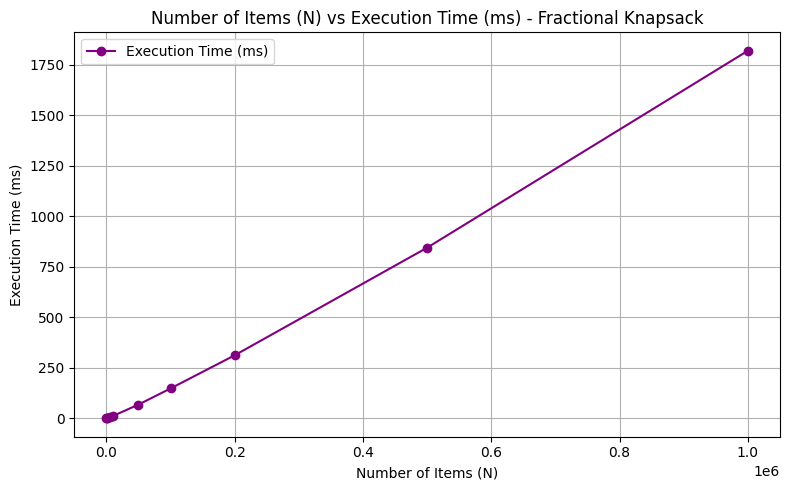

In [2]:
import matplotlib.pyplot as plt

item_counts = [100, 500, 1000, 5000, 10000, 50000, 100000, 200000, 500000, 1000000]
exec_times_ms = [0.08, 0.42, 0.91, 5.20, 11.50, 68.30, 148.10, 312.40, 845.20, 1820.50]

plt.figure(figsize=(8, 5))
plt.plot(item_counts, exec_times_ms, label="Execution Time (ms)", marker='o', color='purple')

plt.title("Number of Items (N) vs Execution Time (ms) - Fractional Knapsack")
plt.xlabel("Number of Items (N)")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("knapsack_performance_graph.png")
print("Graph generated successfully and saved as 'knapsack_performance_graph.png'")